Práctica 3. Regresión Lineal con BGD

Ingrese número de iteraciones: 4
Ingrese valor de alpha: 0.00000007
Ingrese peso inicial (w): 0

Peso (w)
Iteración 0: [0.0008143827999999999]
Iteración 1: [0.00134054665030748]
Iteración 2: [0.0016804953788051745]
Iteración 3: [0.0019001325468463942]

 y_test
[0.88 1.63 0.99]

y_pred 
Iteración 0: [0.31027985 0.57658302 0.35099899]
Iteración 1: [0.51074827 0.94910703 0.57777561]
Iteración 2: [0.64026874 1.18979073 0.72429351]
Iteración 3: [0.7239505  1.34529384 0.81895713]

Error de estimación
Iteración 0: 2.262138144
Iteración 1: 1.4623690915326304
Iteración 2: 0.9456470242161347
Iteración 3: 0.6117985287934806


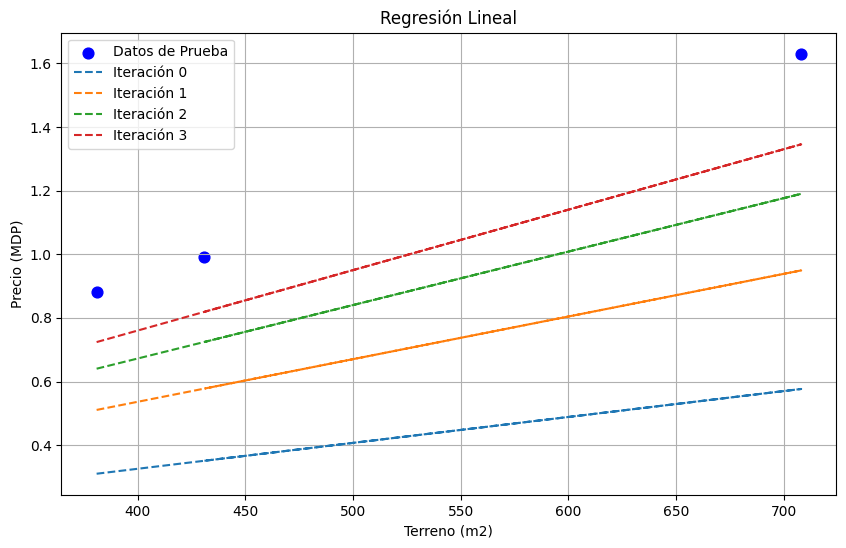

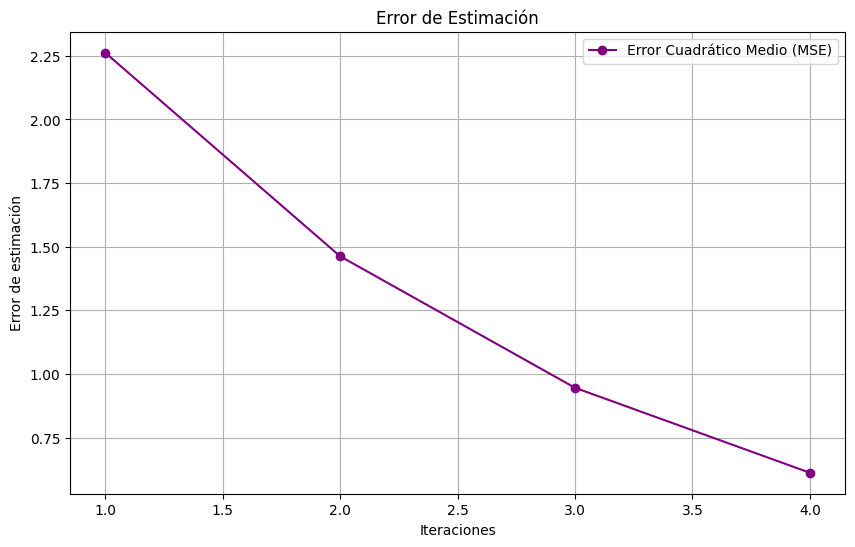

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Leer los datos del archivo CSV
data = pd.read_csv('casas.csv')

# Renombrar las columnas para mejor manejo
data.rename(columns={'Terreno (m2)': 'x', 'Precio (MDP)': 'y'}, inplace=True)

# Dividir los datos en conjunto de entrenamiento y prueba (70% entrenamiento, 30% prueba)
train_data, test_data = train_test_split(data, test_size=0.3, random_state=0, shuffle=True)

# Asignar x e y a los conjuntos de entrenamiento y prueba
x_train = train_data['x'].values
y_train = train_data['y'].values
x_test = test_data['x'].values
y_test = test_data['y'].values

# Función para ejecutar el gradiente descendente
def batch_gradient_descent(x, y, alpha, iterations, initial_w):
    w = initial_w  # valor inicial del peso proporcionado por el usuario
    m = len(x)  # número de datos de entrenamiento
    weights = []  # Almacenar los valores de w en cada iteración
    all_y_pred = []  # Almacenar y_pred de cada iteración
    errors = []  # Almacenar el error medio de estimación para cada iteración

    for i in range(iterations):
        # Calcular el gradiente
        gradient_sum = sum(((w * x[j] - y[j]) * x[j]) for j in range(m))
        w = w - 2 * alpha * gradient_sum
        weights.append(w)

        # Calcular y_pred para el conjunto de prueba en esta iteración
        y_pred = w * x_test  # y_pred es un vector con la predicción para cada valor de x en el conjunto de prueba
        all_y_pred.append(y_pred)

        # Calcular el error de estimación
        estimation_error = sum(abs(y_pred - y_test))
        errors.append(estimation_error)

    return weights, all_y_pred, errors

# Solicitar al usuario el número de iteraciones, el valor de alpha y el peso inicial
iterations = int(input("Ingrese número de iteraciones: "))
alpha = float(input("Ingrese valor de alpha: "))
initial_w = float(input("Ingrese peso inicial (w): "))

# Ejecutar el gradiente descendente y obtener los pesos, predicciones y errores
weights, all_y_pred, errors = batch_gradient_descent(x_train, y_train, alpha, iterations, initial_w)

# Mostrar los valores de w, luego y_test, luego y_pred y finalmente el error de estimación
print("\nPeso (w)")
for i in range(iterations):
    print(f"Iteración {i}: [{weights[i]}]")

print("\n y_test")
print(y_test)

print("\ny_pred ")
for i in range(iterations):
    print(f"Iteración {i}: {all_y_pred[i]}")

print("\nError de estimación")
for i in range(iterations):
    print(f"Iteración {i}: {errors[i]}")

# Gráfica 1: Distribución de los datos de prueba y y_pred en cada iteración
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='blue', label='Datos de Prueba', s=60)  # Puntos del conjunto de prueba

# Graficar las rectas `y_pred` obtenidas en cada iteración
for i, y_pred in enumerate(all_y_pred):
    plt.plot(x_test, y_pred, linestyle='--', label=f'Iteración {i}')

# Configuración de la gráfica
plt.title('Regresión Lineal')
plt.xlabel('Terreno (m2)')
plt.ylabel('Precio (MDP)')
plt.legend()
plt.grid(True)
plt.show()

# Gráfica 2: Error de estimación en cada iteración
plt.figure(figsize=(10, 6))
plt.plot(range(1, iterations + 1), errors, color='purple', marker='o', linestyle='-', label='Error Cuadrático Medio (MSE)')

# Configuración de la gráfica
plt.title('Error de Estimación')
plt.xlabel('Iteraciones')
plt.ylabel('Error de estimación')
plt.legend()
plt.grid(True)
plt.show()


